**Assignment 2**


**Question 1**


First, we import the required packages and load the dataset.

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from torch.utils.data import Dataset, DataLoader

# Set to True if using ml.p2.xlarge Instances
FLAG_GPU = False


transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=0.5, std=1.0)])
dataset = datasets.MNIST(root='../data', download=True, transform=transform)



We then reshape the data into a matrix $X \in \mathbb{R}^{60000 \times 784}$ and centre each feature column.

In [2]:
X = dataset.data.float().reshape(len(dataset), -1)
column_means = X.mean(dim=0, keepdim=True)
X -= column_means
print(X.shape)

torch.Size([60000, 784])


We can now compute the SVD of the centred data matrix $X$.


In [3]:
U, S, Vh = torch.linalg.svd(X, full_matrices=False)
print("Shape of U, S and Vh:\n", U.shape, S.shape, Vh.shape)

Shape of U, S and Vh:
 torch.Size([60000, 784]) torch.Size([784]) torch.Size([784, 784])


After computing the SVD of $X$, we can extract the first two principal directions from the matrix $V$.


In [4]:
# First two principal directions
V_2 = Vh[:2, :].T           # shape: [784, 2]

# PCA coordinates for every image
X_pca = X @ V_2             # shape: [60000, 2]

print(X_pca.shape)

torch.Size([60000, 2])


We can then plot the projection onto the first two principal components as follows.


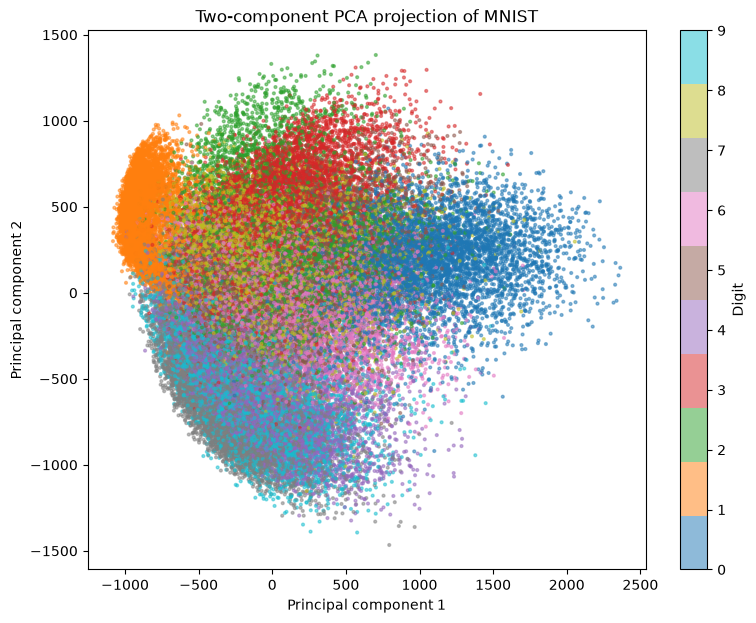

In [5]:
labels = dataset.targets

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0].cpu(),
    X_pca[:, 1].cpu(),
    c=labels.cpu(),
    cmap="tab10",
    s=4,
    alpha=0.5
)

plt.colorbar(scatter, label="Digit")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Two-component PCA projection of MNIST")
plt.show()

In this plot of the first two principal components of the dataset, there is a large amount of data and some overlap between classes, but each digit remains largely clustered with other examples of the same digit.


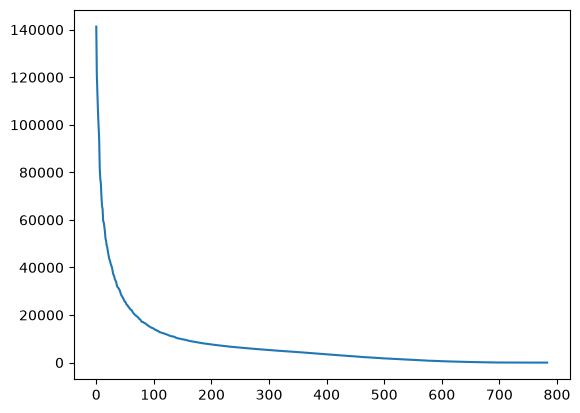

In [6]:
plt.plot(S)

**Is there an "elbow"; or equivalently, do a small number of singular values explain most of the variance in the data?**

The scree plot shows an initial steep decrease in the singular values, followed by a gradual flattening. There is an elbow, although it is fairly broad, and there is no single point at which the curve becomes completely flat. This suggests that the first few components capture a large proportion of the total variance in the data.


**With reference to the previous answer, we can assess whether PCA could be used to form a low-dimensional representation of the dataset.**

PCA can be used to form a low-dimensional representation of the data, since the decreasing singular values show that most of the information is captured by the first few principal components. In this case, the first few singular values explain much of the variance, so a representation with dimension smaller than 784 is reasonable. More than two components would likely be needed for a faithful reconstruction, but the data can still be compressed to a much lower dimension than the original 784 features.


**Question 2**

Research a second dimension reduction technique (there are possibilities listed in the text) and implement it to generate a similar (in nature) two-dimensional scatter plot to the one shown above.

The second dimension reduction technique I chose to implement is a variational autoencoder (VAE), because it is a standard deep-learning approach and is well suited to learning a compact latent representation of the data.


Epoch 1: loss = 190.0920
Epoch 2: loss = 167.8603
Epoch 3: loss = 163.5484
Epoch 4: loss = 161.2579
Epoch 5: loss = 159.4773
Epoch 6: loss = 158.0378
Epoch 7: loss = 156.8952
Epoch 8: loss = 155.8255
Epoch 9: loss = 154.9692
Epoch 10: loss = 154.2049


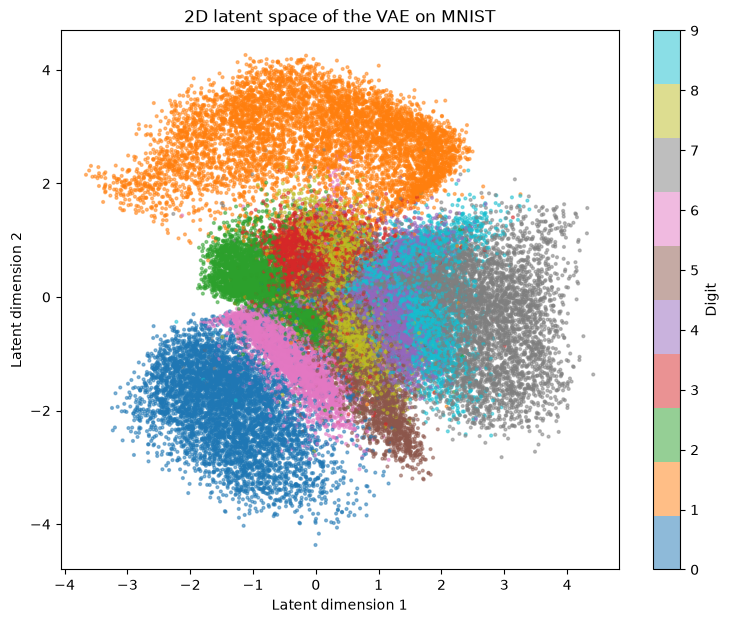

In [7]:
X_vae = dataset.data.float().reshape(len(dataset), -1) / 255.0

latent_dim = 2

class VAE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(784, 400),
            torch.nn.ReLU()
        )
        self.mu_head = torch.nn.Linear(400, latent_dim)
        self.logvar_head = torch.nn.Linear(400, latent_dim)

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 400),
            torch.nn.ReLU(),
            torch.nn.Linear(400, 784),
            torch.nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar


def loss_function(recon_x, x, mu, logvar):
    bce = torch.nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld


model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

loader = torch.utils.data.DataLoader(
    X_vae,
    batch_size=128,
    shuffle=True
)

for epoch in range(1, 11):
    model.train()
    total_loss = 0.0

    for batch_x in loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(batch_x)
        loss = loss_function(recon, batch_x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}: loss = {total_loss / len(X_vae):.4f}")

with torch.no_grad():
    mu, _ = model.encode(X_vae)
    z = mu.numpy()

labels = dataset.targets.numpy()

plt.figure(figsize=(9, 7))
plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", s=4, alpha=0.5)
plt.colorbar(label="Digit")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("2D latent space of the VAE on MNIST")
plt.show()

**Question 3**

For this question I will prove that ReLU is a convex function. ReLU is defined as:

$$
f(x_i)=\max(0,x_i)
$$
and to establish convexity we must show that:
$$
\lambda f(x_1)+(1-\lambda)f(x_2) \geq f(\lambda x_1 + (1-\lambda)x_2) \text{ where } 0 \leq \lambda \leq 1 \\
$$
When we substitute in ReLU: 
$$
\lambda \max(0,x_1)+(1-\lambda)\max(0,x_2) \geq \max(0, \lambda x_1 + (1-\lambda)x_2)
$$
Since $\max(0,x_i) \geq x_i$ and both $\lambda,\  1 - \lambda \geq 0$,
$$
\lambda \max(0,x_1)+(1-\lambda)\max(0,x_2) \geq \lambda x_1 + (1-\lambda)x_2
$$
With the both terms on the left hand side being nonnegative, the left-hand is therefore at least maximum of these two lower bounds.
$$
\lambda \max(0,x_1)+(1-\lambda)\max(0,x_2) \geq \max(0, \lambda x_1 + (1-\lambda)x_2)
$$
This establishes the convexity inequality $\forall \  x_1,x_2 \in \mathbb{R}$ and $\lambda \in [0,1]$. Hence ReLU is a convex function.

Discussion in relation to NN.


**Question 4**

MLPNet(
  (fc0): Linear(in_features=784, out_features=256, bias=True)
  (fc1): Linear(in_features=256, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)
shape of images torch.Size([32, 1, 28, 28])


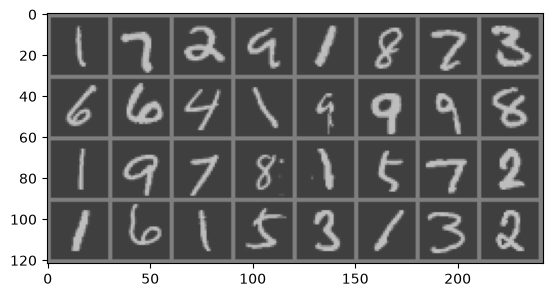

Labels were:
[[1 7 2 9 1 8 7 3]
 [6 6 4 1 9 9 9 8]
 [1 9 7 8 1 5 7 2]
 [1 6 1 5 3 1 3 2]]


In [13]:
class MLPNet(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()

        layers = [nn.Flatten()]
        input_size = 784

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))
        layers.append(nn.LogSoftmax(dim=1))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

# Training and test datasets
trainset = datasets.MNIST(root='../data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)

testset = datasets.MNIST(root='../data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

if FLAG_GPU:
    net.cuda()
    print(net)
else:
    print(net)


def imshow(img, l):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    print('Labels were:')
    print(l.reshape(-1, 8).numpy())


# Load a sample batch of training data
images, labels = next(iter(trainloader))
print('shape of images', images.shape)

# Display the batch
imshow(utils.make_grid(images), labels)

criterion = nn.NLLLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
if FLAG_GPU:
    criterion = criterion.cuda()

In [14]:
shallow = MLPNet([288])
deep = MLPNet([192, 192, 192])

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Shallow:", count_parameters(shallow))
print("Deep:", count_parameters(deep))

Shallow: 228970
Deep: 226762


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep evaluation batching fixed throughout the experiments.
testloader = DataLoader(
    testset, batch_size=1024, shuffle=False, num_workers=0
)

def run_experiment(hidden_sizes, batch_size, seed):
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    # Separate generator makes data ordering independent of model size.
    generator = torch.Generator().manual_seed(seed)

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0
    )

    net = MLPNet(hidden_sizes).to(device)
    criterion = nn.NLLLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    history = []
    total_training_time = 0.0

    for epoch in range(5):
        net.train()
        total_loss = 0.0

        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()

        for inputs, labels in trainloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Weight by batch size because the final batch may be smaller.
            total_loss += loss.item() * labels.size(0)

        if device.type == "cuda":
            torch.cuda.synchronize()
        total_training_time += time.perf_counter() - start

        net.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                predictions = net(inputs).argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        history.append({
            "epoch": epoch + 1,
            "train_loss": total_loss / len(trainset),
            "test_accuracy": 100 * correct / total
        })

    return {
        "seed": seed,
        "batch_size": batch_size,
        "parameters": count_parameters(net),
        "accuracy": history[-1]["test_accuracy"],
        "training_seconds": total_training_time,
        "history": history
    }

In [16]:
architectures = {
    "Shallow": [288],
    "Deep": [192, 192, 192]
}

seeds = range(5)
architecture_results = []

for name, hidden_sizes in architectures.items():
    for seed in seeds:
        result = run_experiment(hidden_sizes, batch_size=64, seed=seed)
        result["architecture"] = name
        architecture_results.append(result)

        print(name, seed, round(result["accuracy"], 2))

Shallow 0 97.23
Shallow 1 97.26
Shallow 2 97.03
Shallow 3 96.52
Shallow 4 96.81
Deep 0 97.27
Deep 1 96.48
Deep 2 96.32
Deep 3 96.94
Deep 4 96.68


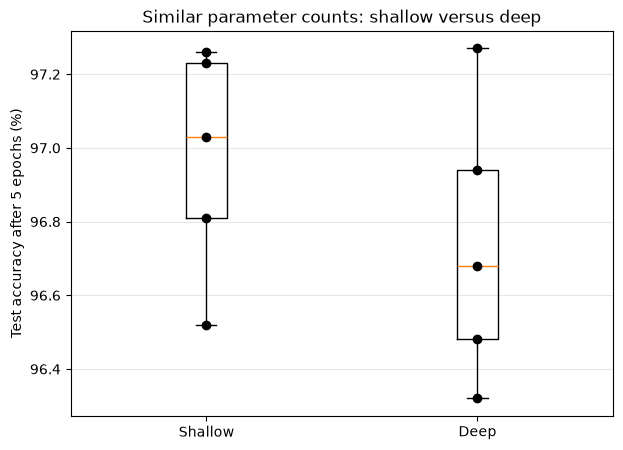

In [17]:
names = list(architectures)
scores = [
    [r["accuracy"] for r in architecture_results
     if r["architecture"] == name]
    for name in names
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(scores)

for position, values in enumerate(scores, start=1):
    ax.scatter([position] * len(values), values, color="black", zorder=3)

ax.set_xticks([1, 2])
ax.set_xticklabels(names)
ax.set_ylabel("Test accuracy after 5 epochs (%)")
ax.set_title("Similar parameter counts: shallow versus deep")
ax.grid(axis="y", alpha=0.3)
plt.show()

In [18]:
batch_sizes = [8, 32, 128, 512, 2048, 4096]
batch_results = []

for batch_size in batch_sizes:
    for seed in seeds:
        result = run_experiment([288], batch_size, seed)
        batch_results.append(result)

        print(batch_size, seed, round(result["accuracy"], 2))

8 0 96.64
8 1 96.94
8 2 96.23
8 3 96.77
8 4 95.83
32 0 97.29
32 1 97.22
32 2 96.78
32 3 96.62
32 4 96.79
128 0 97.19
128 1 97.09
128 2 96.8
128 3 96.89
128 4 96.91
512 0 95.0
512 1 95.02
512 2 94.53
512 3 95.3
512 4 94.65
2048 0 91.67
2048 1 91.72
2048 2 92.12
2048 3 91.89
2048 4 91.94
4096 0 90.58
4096 1 90.31
4096 2 90.74
4096 3 90.64
4096 4 90.75


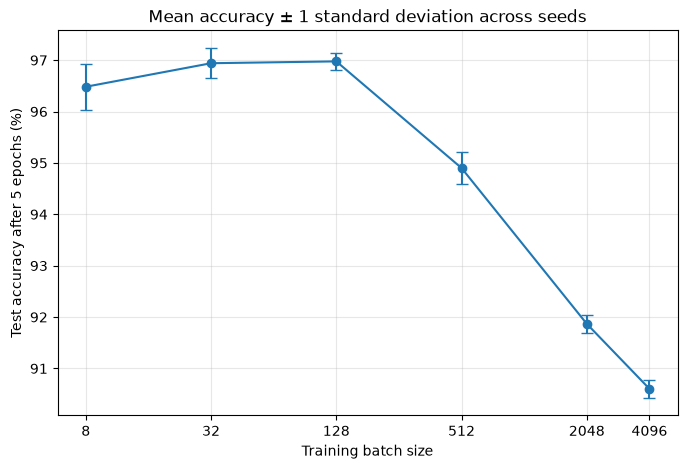

In [19]:
means = [
    np.mean([r["accuracy"] for r in batch_results
             if r["batch_size"] == b])
    for b in batch_sizes
]

stds = [
    np.std([r["accuracy"] for r in batch_results
            if r["batch_size"] == b], ddof=1)
    for b in batch_sizes
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(batch_sizes, means, yerr=stds, fmt="o-", capsize=4)
ax.set_xscale("log", base=2)
ax.set_xticks(batch_sizes)
ax.set_xticklabels(batch_sizes)
ax.set_xlabel("Training batch size")
ax.set_ylabel("Test accuracy after 5 epochs (%)")
ax.set_title("Mean accuracy ± 1 standard deviation across seeds")
ax.grid(alpha=0.3)
plt.show()